# Time Series Analysis
### End to End time series analysis - EDA, time series visualization, and modeling

In [637]:
# General Data Science Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Time Series Specific Libraries
from statsmodels.tsa.seasonal import STL # Seasonal-Trend decomposition using LOESS
from statsmodels.tsa.stattools import acf, pacf # Functions for computing autocorrelation and partial autocorrelation
from statsmodels.stats.diagnostic import acorr_ljungbox # Function for performing the Ljung-Box test for autocorrelation
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # Functions for plotting autocorrelation and partial autocorrelation


## Below libraries are Nixtla ecosystem and will require ds, y, unique_id consistently
# Utility functions for time series analysis
from utilsforecast.plotting import plot_series # A utility function to plot time series data
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, mape, smape, mase, mse

from statsforecast.utils import AirPassengersDF # A sample dataset of monthly airline passenger numbers from 1949 to 1960
from statsforecast import StatsForecast # A library for forecasting time series data using various statistical models
from statsforecast.models import (Naive, SeasonalNaive, WindowAverage, HistoricAverage, RandomWalkWithDrift)
from mlforecast import MLForecast # A library for forecasting time series data using machine learning models



- In the dataset, the data has monthly values, sampled at end of the month. 144 entries.
- Unique_id is to take care of multiple time series like separate for domestic vs international.
- I expect to see an uptrend in the timeseries, with high coefficient of variation and high/low =6x.
- There are 12 seasonal cycles (Which is >5 appropriate for a model to learn the patterns, however not great for Deep learning models)
- I would expect an uptick in the aviation business and airline indutstry given the world was opening up more, the economy improved in this time period, travel both for leisure and business should have increased and typically expect to see more travels around the holidays
- I'd expect a summer peak (July-August, vacation travel in the Northern Hemisphere) and a secondary December peak (Christmas/holiday travel). Troughs in February and November. The seasonal amplitude should grow with the trend — i.e., a multiplicative pattern, not additive — because as the market grows, the absolute summer spike grows with it.

In [638]:
df = AirPassengersDF.copy()
print('-' * 50)
print(df.info())
print('-' * 50)
print(df['y'].describe())
print('-' * 50)
print("Date Range: {} to {}".format(df['ds'].min(), df['ds'].max()))
print('-' * 50)
print('Coefficient of Variation (CV): {:.2f}'.format(df['y'].std() / df['y'].mean()))

--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   unique_id  144 non-null    float64       
 1   ds         144 non-null    datetime64[ns]
 2   y          144 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 3.5 KB
None
--------------------------------------------------
count    144.000000
mean     280.298611
std      119.966317
min      104.000000
25%      180.000000
50%      265.500000
75%      360.500000
max      622.000000
Name: y, dtype: float64
--------------------------------------------------
Date Range: 1949-01-31 00:00:00 to 1960-12-31 00:00:00
--------------------------------------------------
Coefficient of Variation (CV): 0.43


#### Hard requirements in statsforecast
statsforecast (and the entire Nixtla ecosystem — mlforecast, neuralforecast, hierarchicalforecast, utilsforecast) requires these three exact column names:
unique_id — series identifier
ds — datestamp
y — target variable


## Part 1: Visualization of timeseries
### 1.1 Hypothesis-First EDA



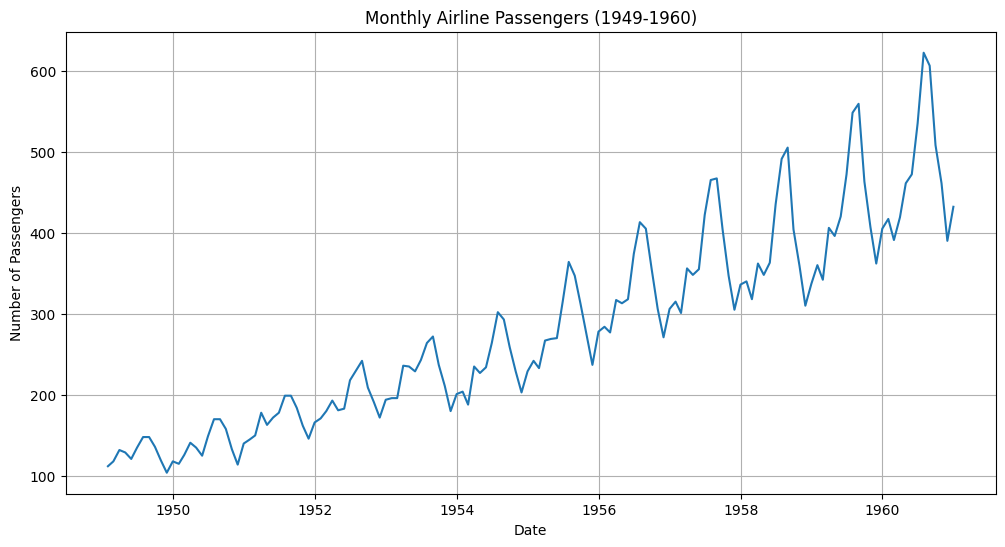

In [639]:

# Plotting the time series:
plt.figure(figsize=(12, 6))
plt.plot(df['ds'], df['y'])
plt.title('Monthly Airline Passengers (1949-1960)')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.grid()
plt.show()



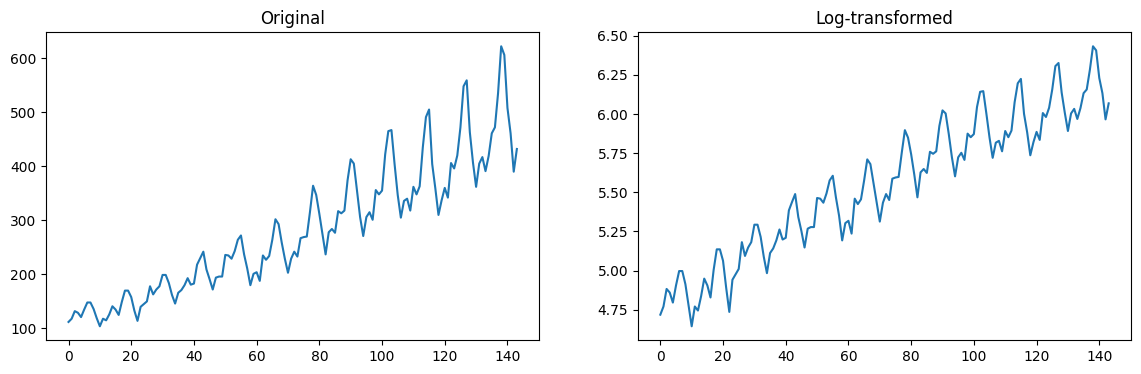

In [640]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['y'].plot(ax=axes[0], title='Original')
np.log(df['y']).plot(ax=axes[1], title='Log-transformed')
plt.show()

### 1.2 Trend Shape Diagnosis and STL Decomposition
Heuristic: If seasonal amplitude grows with the level, seasonality is multiplicative. Often co-occurs with exponential trend. Log transform converts both to additive — at which point every additive modeling method (SARIMA, linear ETS, linear regression on lags) is back on the table.



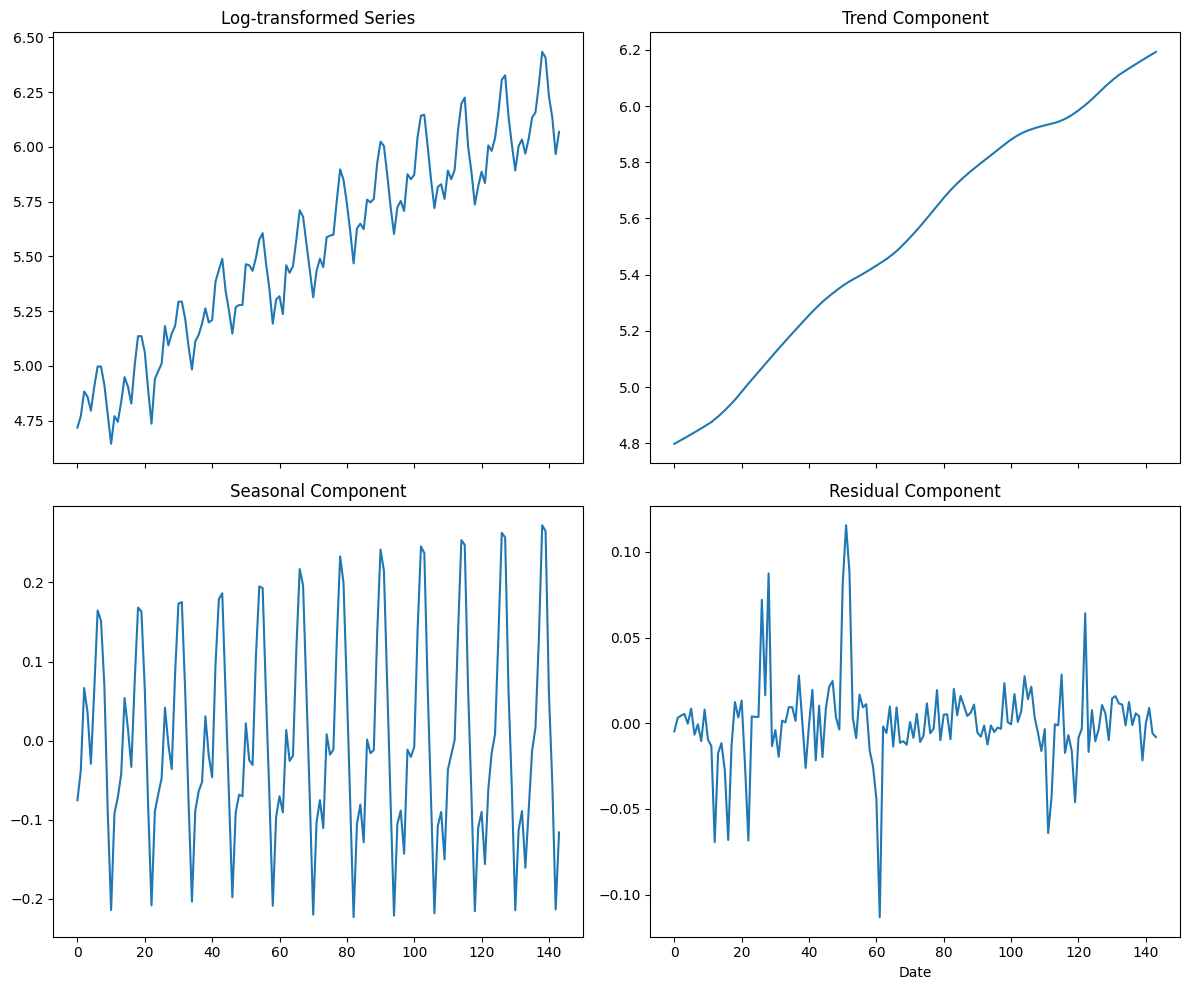

In [641]:
# Log transformation to stabilize variance and convert multiplicative seasonality to additive
df['log_y'] = np.log(df['y'])

# STL decomposition to separate trend, seasonality, and residuals
stl = STL(df['log_y'], period=12, robust=True)  # Assuming monthly data with yearly seasonality
result = stl.fit()

# Extracting the components:
df['log_trend'] = result.trend
df['log_seasonal'] = result.seasonal
df['log_residual'] = result.resid
df['trend'] = np.exp(df['log_trend'])
df['seasonal'] = np.exp(df['log_seasonal'])
df['residual'] = np.exp(df['log_residual'])

# plotting the components:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
df['log_y'].plot(ax=axes[0, 0], title='Log-transformed Series')
df['log_trend'].plot(ax=axes[0, 1], title='Trend Component')
df['log_seasonal'].plot(ax=axes[1, 0], title='Seasonal Component')
df['log_residual'].plot(ax=axes[1, 1], title='Residual Component')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

- Trend:Smooth increasing trend, however very subtle changes in slope to a point where the change is unnoticable
- Seasonal: Shape is stabe across with each year showing two peaks - one small and one large peak. The larger peak shows linear slight increase in amplitude over time.
- Residual Plot: The residual panel shows random scatter around zero with no visible pattern

### Visualizing the seasonal patterns now:

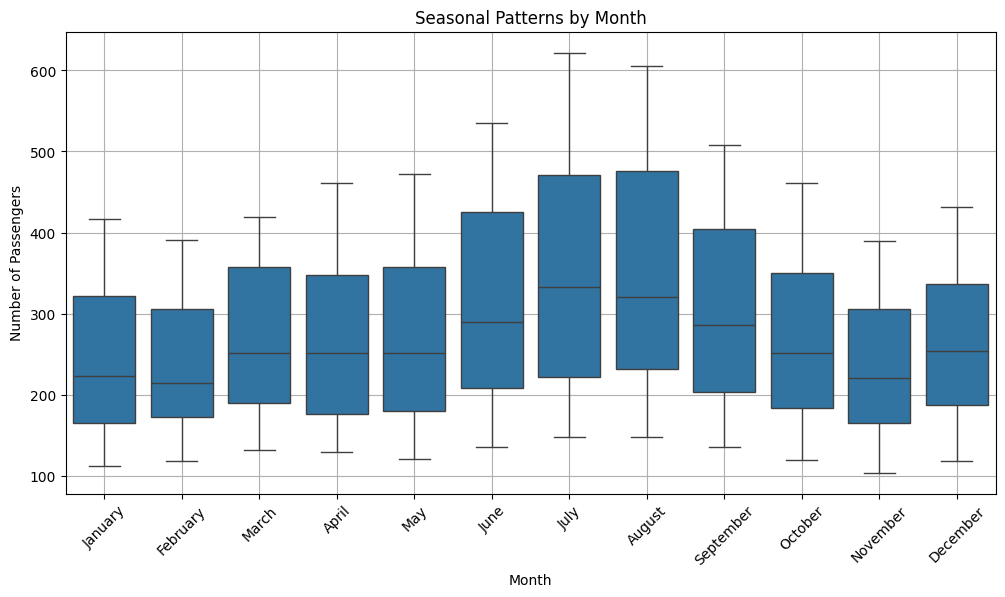

In [642]:
df_agg = df.assign(
    year=df['ds'].dt.year,
    month=df['ds'].dt.month,
    month_name=df['ds'].dt.month_name()
)
# Plot seasonal patterns by month:
plt.figure(figsize=(12, 6))
sns.boxplot(x='month_name', y='y', data=df_agg, order=[
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])
plt.title('Seasonal Patterns by Month')
plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=45)
plt.grid()

## Multiple seasonal periods

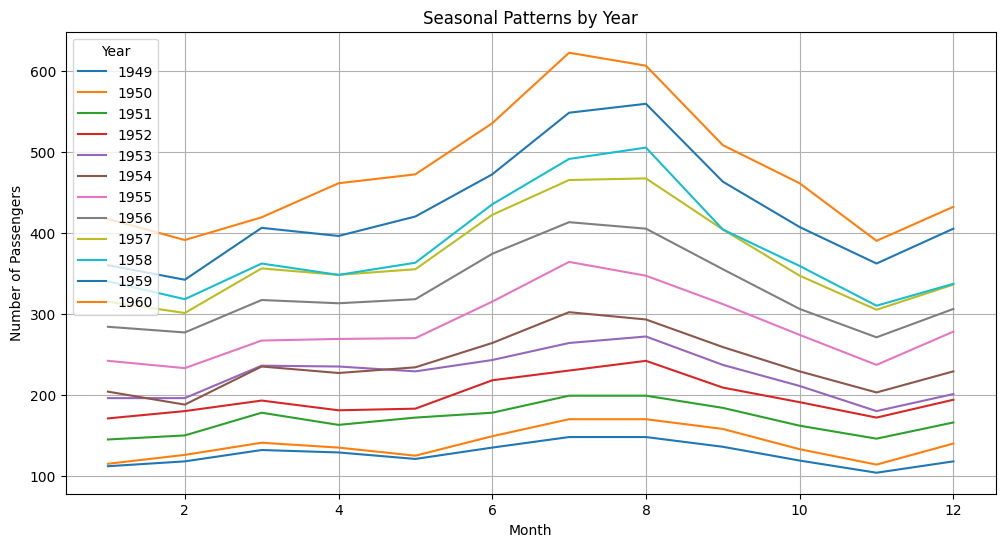

In [643]:
# Plotting the monthly patterns by year:
plt.figure(figsize=(12, 6))
for year, group in df_agg.groupby('year'):
    plt.plot(group['month'], group['y'], label=str(year))
plt.title('Seasonal Patterns by Year')
plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.legend(title='Year')
plt.grid()
plt.show()

## Pat 2. Custom Seasonal Subseries Plot
Built a 12-panel month-by-month plot with STL trend overlay. Visualized that July/August actuals sit progressively above trend (widening gap) while November sits below — making the multiplicative seasonality visible without explicit decomposition.

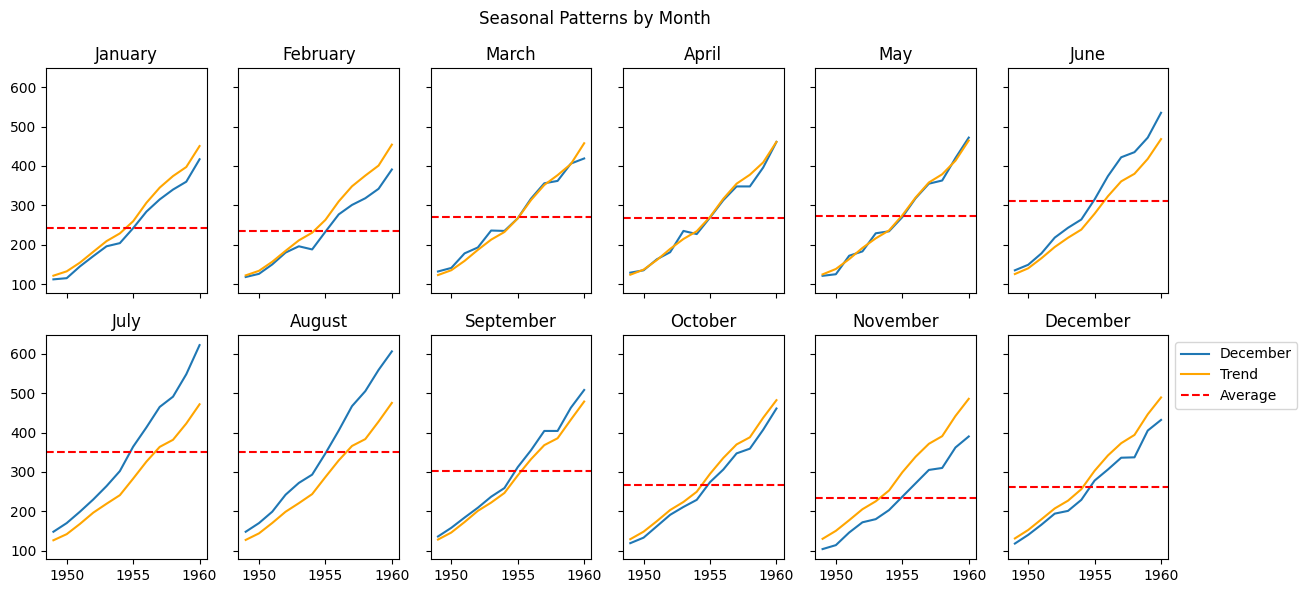

In [644]:
fig, axes = plt.subplots(nrows = 2, ncols = 6, figsize = (12,6), sharey = True, sharex = True)
for (month, group), ax in zip(df_agg.groupby('month'), axes.flatten()):
    ax.plot(group['year'], group['y'], label=group['month_name'].iloc[0])
    ax.plot(group['year'], group['trend'], label='Trend', color='orange')
    ax.axhline(group['y'].mean(), color='red', linestyle='--', label='Average')
    ax.set_title(group['month_name'].iloc[0])
# Super title:
plt.suptitle('Seasonal Patterns by Month')
plt.tight_layout()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

## Part 3 Autocorrelation analysis and Residual Diagnostics 

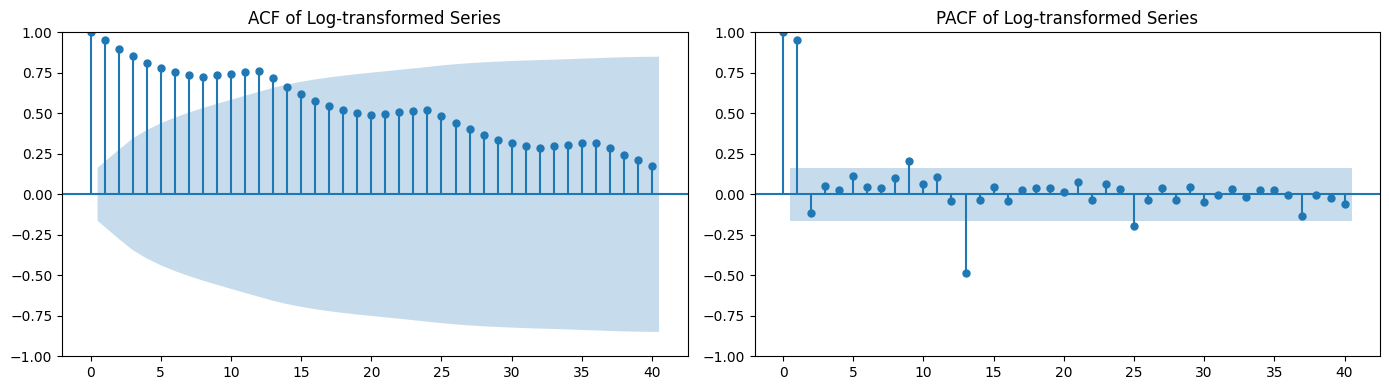

In [645]:

# Calculating ACF and PACF for the log-transformed series:
lag_acf = acf(df['log_y'], nlags=40)
lag_pacf = pacf(df['log_y'], nlags=40)

# Plotting ACF and PACF:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df['log_y'], lags=40, ax=axes[0])
plot_pacf(df['log_y'], lags=40, ax=axes[1])
axes[0].set_title('ACF of Log-transformed Series')
axes[1].set_title('PACF of Log-transformed Series')
plt.tight_layout()
plt.show()


# Performing Residual Analysis
#### Diagnostic plots to analyze how residuals are trending over time and identify autocorrelation between residuals value

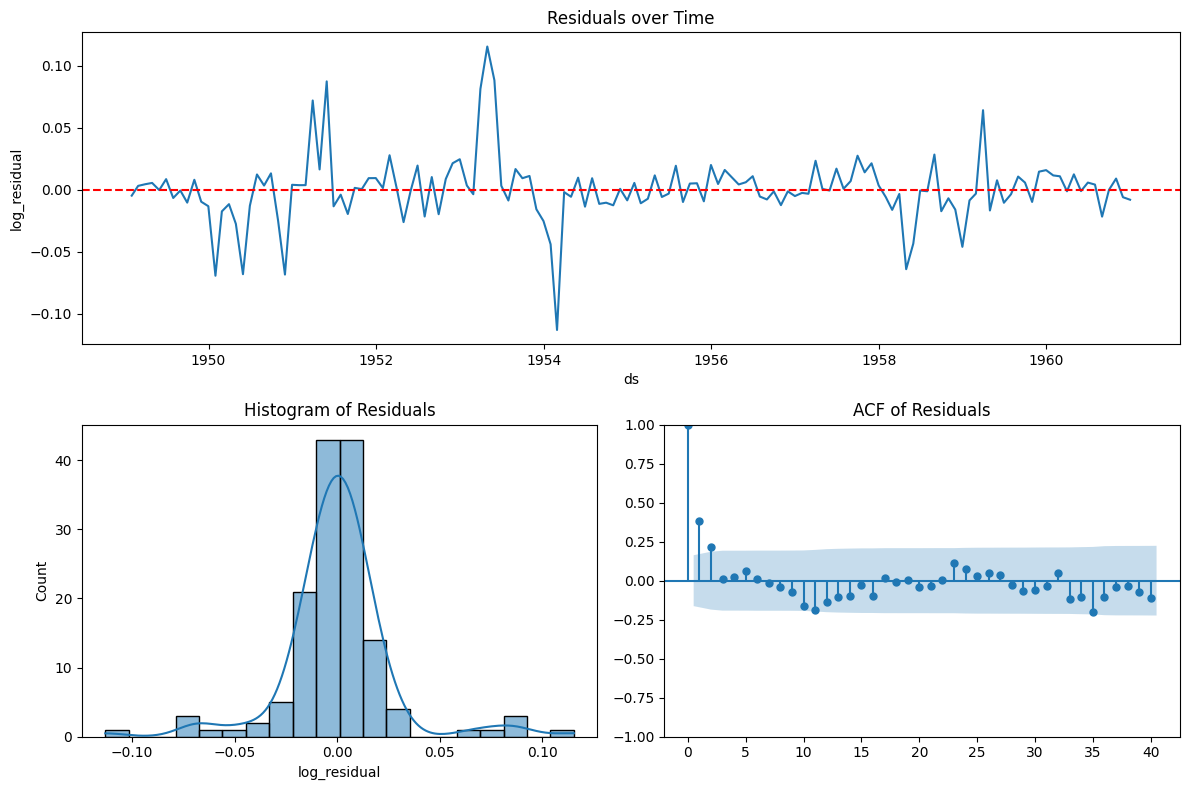

In [646]:
fig,axes = plt.subplot_mosaic([['residual_trend', 'residual_trend'], ['histogram', 'acf']], figsize=(12, 8))

# Residual plot
sns.lineplot(x= 'ds', y='log_residual', data=df, ax=axes['residual_trend'])
axes['residual_trend'].set_title('Residuals over Time')
axes['residual_trend'].axhline(0, color='red', linestyle='--')
# Histogram of residuals:
sns.histplot(df['log_residual'], bins=20, kde=True, ax=axes['histogram'])
axes['histogram'].set_title('Histogram of Residuals')
# ACF of residuals:
plot_acf(df['residual'], lags=40, ax=axes['acf'])
axes['acf'].set_title('ACF of Residuals')
plt.tight_layout()
plt.show()

STL's decomposition captured the trend and seasonal signal well, but there's residual short-term autocorrelation at lag 1 (and maybe lag 2). In plain English: "After removing trend and seasonality, the residual in month t is still somewhat predictable from the residual in month t-1."


**Insight:** STL residuals showed lag-1 autocorrelation ≈ 0.3, significantly above the confidence band. Decomposition alone is not a forecasting model — it separates trend/seasonality but leaves short-term dynamics in the residual. AR(1) terms in ARIMA exist to capture exactly this remaining structure.


### Part 3.2: Ljung-Box Formal Test

In [647]:
residuals = result.resid.dropna()
lb = acorr_ljungbox(residuals, lags=[6, 12, 24], return_df=True)
print("\nLjung-Box test results:")
for lag in [6, 12, 24]:
    p_value = lb.loc[lag, 'lb_pvalue']
    print(f"Lag {lag}: p-value = {p_value:.4f} {'(Significant autocorrelation)' if p_value < 0.05 else '(No significant autocorrelation)'}")
print("All three p-values are massively below 0.05 — essentially zero. \nThe null hypothesis that residuals are independent at these lags is decisively rejected. \nThis confirms the presence of significant autocorrelation in the residuals, especially at lag 1 (and possibly lag 2), which aligns with our earlier ACF plot observations.")



Ljung-Box test results:
Lag 6: p-value = 0.0001 (Significant autocorrelation)
Lag 12: p-value = 0.0000 (Significant autocorrelation)
Lag 24: p-value = 0.0014 (Significant autocorrelation)
All three p-values are massively below 0.05 — essentially zero. 
The null hypothesis that residuals are independent at these lags is decisively rejected. 
This confirms the presence of significant autocorrelation in the residuals, especially at lag 1 (and possibly lag 2), which aligns with our earlier ACF plot observations.


### STL captured trend and seasonality adequately, but residuals show exploitable short-term autocorrelation — a forecasting model should improve on pure decomposition-based prediction.

## Part 4: Forecasting with Base models - Train/Test Split and Baselines

In [648]:
from statsforecast.models import (Naive, SeasonalNaive, WindowAverage, HistoricAverage, RandomWalkWithDrift)

naive = Naive()
seasonalNaive = SeasonalNaive(season_length=12)
# windowAverage = WindowAverage(window_size=12)
historicAverage = HistoricAverage()
RWWD = RandomWalkWithDrift()

cutoff = pd.Timestamp('1955-12-31')

df_new = AirPassengersDF.copy()
train = (df_new.loc[lambda x: (x['unique_id'] == 1) & (x['ds'] <= cutoff)])
test =  (df_new.loc[lambda x: (x['unique_id'] == 1) & (x['ds'] > cutoff)])

sf = StatsForecast(models=[naive, seasonalNaive, historicAverage, RWWD], freq='ME', n_jobs=-1)
sf.fit(df = train)
forecast = sf.predict(h=test.shape[0],level=[80, 95])
test = test.merge(forecast, on=['unique_id', 'ds'], how='left')
test.head()

,unique_id,ds,y,Naive,Naive-lo-80,Naive-lo-95,Naive-hi-80,Naive-hi-95,SeasonalNaive,SeasonalNaive-lo-80,...,HistoricAverage,HistoricAverage-lo-80,HistoricAverage-lo-95,HistoricAverage-hi-80,HistoricAverage-hi-95,RWD,RWD-lo-80,RWD-lo-95,RWD-hi-80,RWD-hi-95
0,1.0,1956-01-31,284.0,278.0,250.606085,236.104622,305.393915,319.895378,242.0,203.345172,...,197.345238,121.639601,81.563458,273.050875,313.127019,280.0,252.562449,238.037886,307.437551,321.962114
1,1.0,1956-02-29,277.0,278.0,239.259153,218.750988,316.740847,337.249012,233.0,194.345172,...,197.345238,121.639601,81.563458,273.050875,313.127019,282.0,242.967158,222.304420,321.032842,341.695580
2,1.0,1956-03-31,317.0,278.0,230.552347,205.435077,325.447653,350.564923,267.0,228.345172,...,197.345238,121.639601,81.563458,273.050875,313.127019,284.0,235.914342,210.459332,332.085658,357.540668
3,1.0,1956-04-30,313.0,278.0,223.212169,194.209244,332.787831,361.790756,269.0,230.345172,...,197.345238,121.639601,81.563458,273.050875,313.127019,286.0,230.153581,200.590272,341.846419,371.409728
4,1.0,1956-05-31,318.0,278.0,216.745343,184.319087,339.254657,371.680913,270.0,231.345172,...,197.345238,121.639601,81.563458,273.050875,313.127019,288.0,225.203990,191.961791,350.796010,384.038209


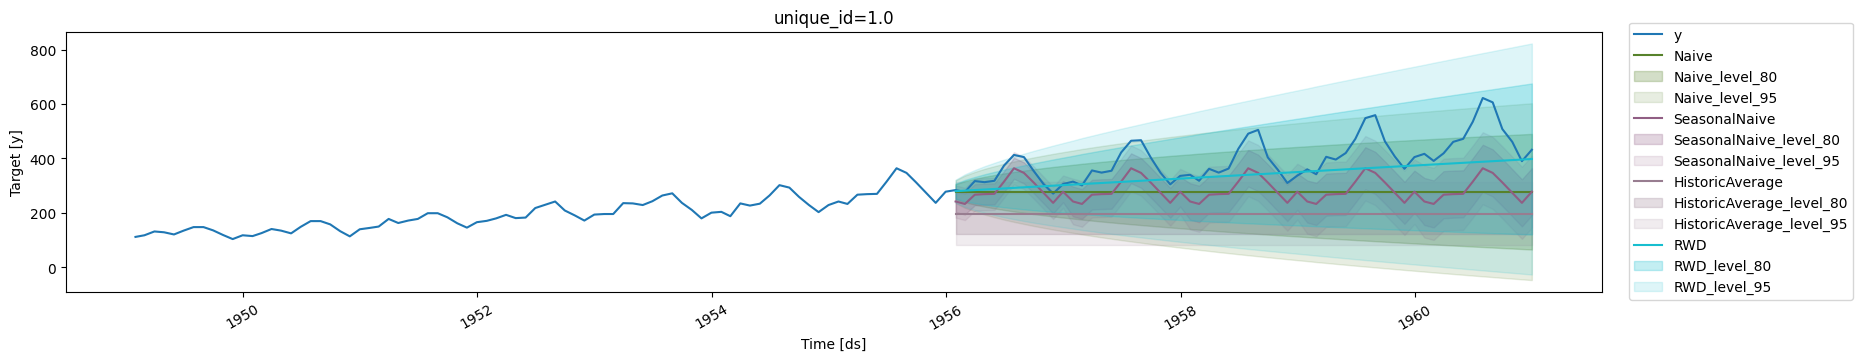

<Figure size 1200x600 with 0 Axes>

In [649]:
# Plotting the time series:
plt.figure(figsize=(12, 6))
plot_series(train,test, level=[80, 95])

### 4.2 Evaluation and the Counterintuitive Result


In [650]:

results = evaluate(test, metrics=[mae, rmse, mape, smape])
print(results)

   unique_id metric       Naive  SeasonalNaive  HistoricAverage        RWD
0        1.0    mae  118.700000     112.433333       199.088095  62.400000
1        1.0   rmse  142.953023     126.013888       214.581411  85.627293
2        1.0   mape    0.272741       0.270469         0.483041   0.139495
3        1.0  smape    0.165114       0.159875         0.323903   0.078388


SeasonalNaive captures seasonality perfectly but misses the trend entirely. It forecasts Jan-1956 = Jan-1955, Feb-1956 = Feb-1955, etc. When the series is still growing at ~12% per year, by the end of the 60-month horizon SeasonalNaive is systematically low by a huge margin — every year it's predicting 1955 values, but the actuals are 1956, 1957, 1958, 1959, 1960.
RWD captures trend via drift but misses seasonality entirely. It forecasts a straight line: last_value + drift × h. Over a 60-month horizon where trend dominates, this is more forgivable than missing trend entirely. The seasonal wiggles become rounding error compared to the massive trend gap SeasonalNaive leaves on the table.
The deep lesson:

When trend is strong and horizon is long, missing trend costs more than missing seasonality.

This is counterintuitive. You looked at the data, saw the dominant feature (multiplicative seasonality — very visible), and assumed the baseline that handled that feature would win. But a strong linear trend compounding over 60 months produces a bigger forecast error than a ~20-30% seasonal swing ever could.

# ETS (Error, Trend and Seasonality Modeling)

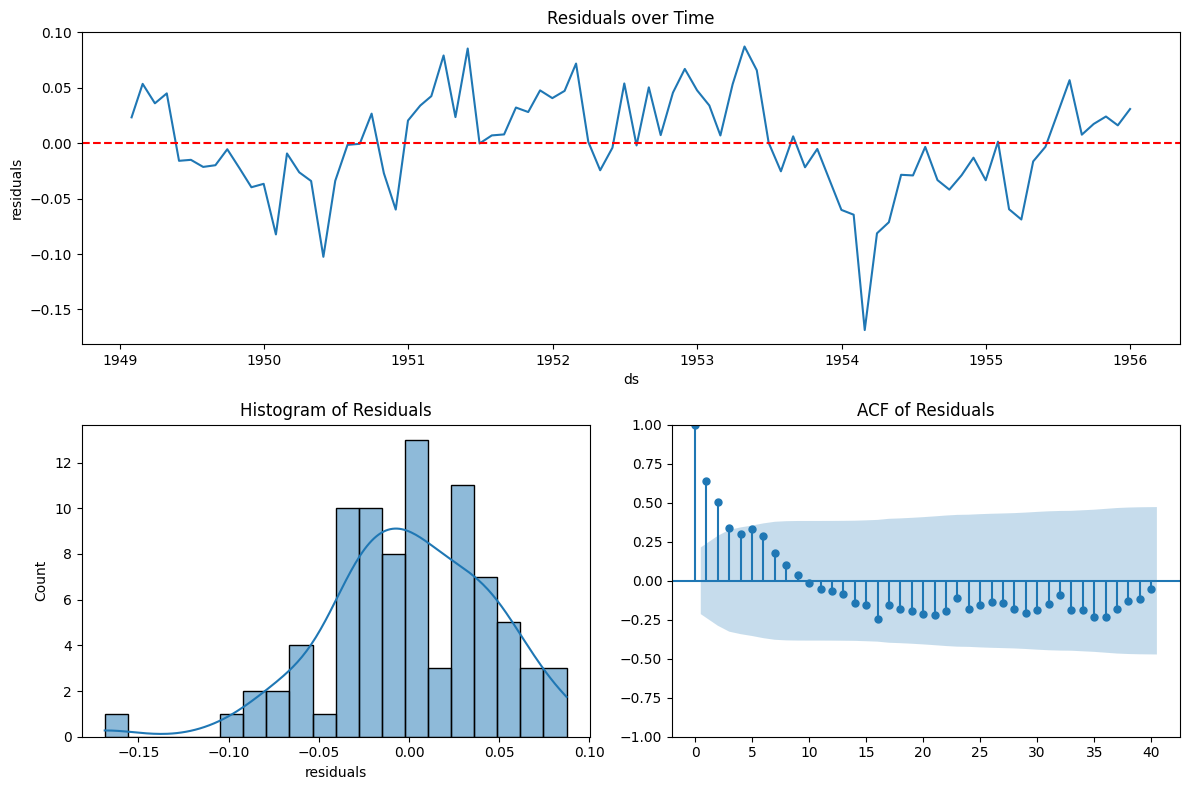


Ljung-Box test results:
Lag 6: p-value = 0.0000 (Significant autocorrelation)
Lag 12: p-value = 0.0000 (Significant autocorrelation)
Lag 24: p-value = 0.0000 (Significant autocorrelation)


In [651]:
import warnings
from xml.parsers.expat import model
warnings.filterwarnings('ignore')

from statsforecast import StatsForecast
from statsforecast.models import AutoETS

df_new = AirPassengersDF.copy()
df_new['y'] = df_new['y'].apply(lambda x: np.log(x) if x > 0 else 0)  # Log-transform the target variable to stabilize variance
train = (df_new.loc[lambda x: (x['unique_id'] == 1) & (x['ds'] <= cutoff)])
test =  (df_new.loc[lambda x: (x['unique_id'] == 1) & (x['ds'] > cutoff)])

ets = AutoETS(season_length=12, model='MAM', alias = 'Seasonal ETS')
ets_model = StatsForecast(models=[ets], freq='ME', n_jobs=-1)

# Single call: fits, forecasts, and stores fitted values
ets_forecast = ets_model.forecast(df=train, h=test.shape[0], level=[80, 95], fitted=True)
fitted_values = ets_model.forecast_fitted_values()

# Merge true y back onto forecasts for plotting/eval
ets_forecast = ets_forecast.merge(test[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')

ets_model.fit(df=train)

## Evaluating the residuals of the fitted model:
fitted_values['residuals'] = fitted_values['y'] - fitted_values['Seasonal ETS']
# Residual plot mosaic:
fig,axes = plt.subplot_mosaic([['residual_trend', 'residual_trend'], ['histogram', 'acf']], figsize=(12, 8))
# Residual plot
sns.lineplot(x= 'ds', y='residuals', data=fitted_values, ax=axes['residual_trend'])
axes['residual_trend'].set_title('Residuals over Time')
axes['residual_trend'].axhline(0, color='red', linestyle='--')
# Histogram of residuals:
sns.histplot(fitted_values['residuals'], bins=20, kde=True, ax=axes['histogram'])
axes['histogram'].set_title('Histogram of Residuals')
# ACF of residuals:
plot_acf(fitted_values['residuals'], lags=40, ax=axes['acf'])
axes['acf'].set_title('ACF of Residuals')
plt.tight_layout()
plt.show()

# Ljung-Box test on residuals:
residuals = fitted_values['residuals'].dropna()
lb = acorr_ljungbox(residuals, lags=[6, 12, 24], return_df=True)
print("\nLjung-Box test results:")
for lag in [6, 12, 24]:
    p_value = lb.loc[lag, 'lb_pvalue']
    print(f"Lag {lag}: p-value = {p_value:.4f} {'(Significant autocorrelation)' if p_value < 0.05 else '(No significant autocorrelation)'}")    


# converting log forecasts back to original scale for plotting:``
train['y'] = np.exp(train['y'])
ets_forecast['y'] = np.exp(ets_forecast['y'])
ets_forecast[f'{ets_model.models[0]}'] = np.exp(ets_forecast[f'{ets_model.models[0]}'])
ets_forecast[f'{ets_model.models[0]}-lo-80'] = np.exp(ets_forecast[f'{ets_model.models[0]}-lo-80'])
ets_forecast[f'{ets_model.models[0]}-hi-80'] = np.exp(ets_forecast[f'{ets_model.models[0]}-hi-80'])
ets_forecast[f'{ets_model.models[0]}-lo-95'] = np.exp(ets_forecast[f'{ets_model.models[0]}-lo-95'])
ets_forecast[f'{ets_model.models[0]}-hi-95'] = np.exp(ets_forecast[f'{ets_model.models[0]}-hi-95'])


# Converting the fitted values back to original scale:
fitted_values['y'] = np.exp(fitted_values['y'])
fitted_values[f'{ets_model.models[0]}'] = np.exp(fitted_values[f'{ets_model.models[0]}'])
fitted_values[f'{ets_model.models[0]}-lo-80'] = np.exp(fitted_values[f'{ets_model.models[0]}-lo-80'])
fitted_values[f'{ets_model.models[0]}-hi-80'] = np.exp(fitted_values[f'{ets_model.models[0]}-hi-80'])
fitted_values[f'{ets_model.models[0]}-lo-95'] = np.exp(fitted_values[f'{ets_model.models[0]}-lo-95'])
fitted_values[f'{ets_model.models[0]}-hi-95'] = np.exp(fitted_values[f'{ets_model.models[0]}-hi-95'])



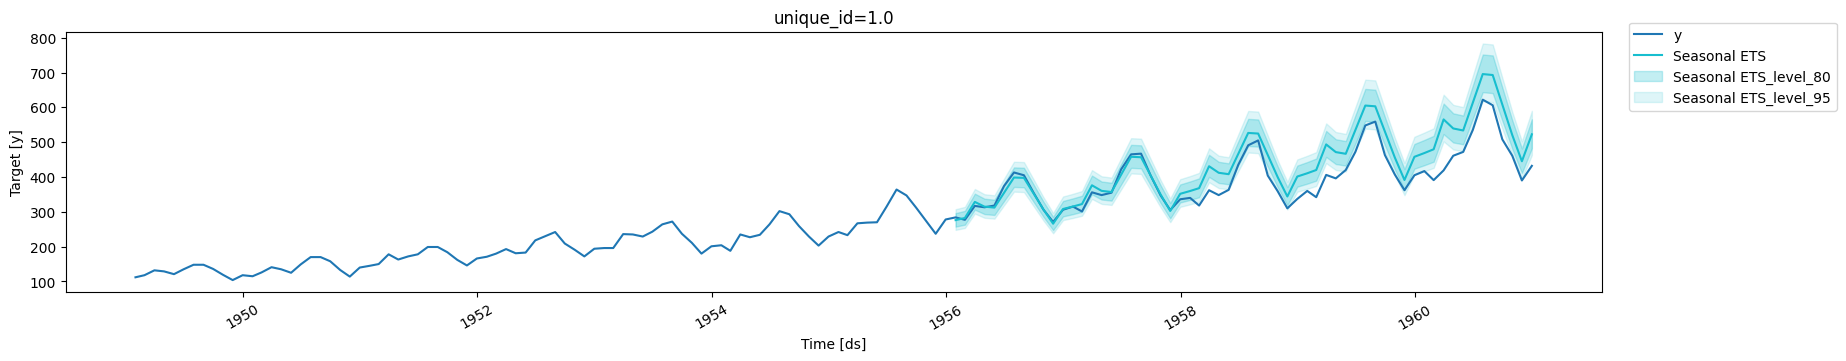

In [652]:

plot_series(train, ets_forecast, level=[80, 95])

In [653]:
fitted_values

,unique_id,ds,y,Seasonal ETS,Seasonal ETS-lo-95,Seasonal ETS-lo-80,Seasonal ETS-hi-80,Seasonal ETS-hi-95,residuals
0,1.0,1949-01-31,112.0,109.412673,99.122046,102.569572,116.712322,120.771650,0.023372
1,1.0,1949-02-28,118.0,111.841458,101.322395,104.846451,119.303148,123.452586,0.053602
2,1.0,1949-03-31,132.0,127.326350,115.350882,119.362858,135.821141,140.545085,0.036048
3,1.0,1949-04-30,129.0,123.324947,111.725824,115.611718,131.552777,136.128265,0.044990
4,1.0,1949-05-31,121.0,122.934063,111.371704,115.245281,131.135814,135.696800,-0.015858
...,...,...,...,...,...,...,...,...,...
79,1.0,1955-08-31,347.0,344.325655,311.940677,322.790168,367.297917,380.072767,0.007737
80,1.0,1955-09-30,312.0,306.613450,277.775432,287.436634,327.069680,338.445367,0.017415
81,1.0,1955-10-31,274.0,267.467828,242.311586,250.739334,285.312392,295.235734,0.024129
82,1.0,1955-11-30,237.0,233.201721,211.268321,218.616365,248.760164,257.412198,0.016156


### Access the fitted AutoETS model inside the StatsForecast wrapper

In [654]:
feature_list = [x for x in dir(ets_model) if not x.startswith('_')]
print(feature_list)

# Evaluations metrics:
eval_metrics = ['loglik', 'aic', 'bic', 'aicc', 'mse', 'amse']
eval_metrics_results = {k:v for k,v in ets_model.fitted_[0,0].model_.items() if k in eval_metrics}
eval_metrics_results = pd.DataFrame(eval_metrics_results, index=[ets_model.models[0]])
print(eval_metrics_results)

# Further Evaluation of the forecasted values:
ets_forecast_eval = evaluate(ets_forecast, metrics=[mae, rmse, mape, smape, mse])
print(ets_forecast_eval)

['cross_validation', 'cross_validation_fitted_values', 'df_constructor', 'fallback_model', 'fcst_fitted_values_', 'fit', 'fit_predict', 'fitted_', 'forecast', 'forecast_fitted_values', 'forecast_times_', 'freq', 'ga', 'id_col', 'last_dates', 'load', 'models', 'n_jobs', 'og_dates', 'plot', 'predict', 'save', 'target_col', 'time_col', 'uids', 'verbose']
                 loglik         aic        bic        aicc       mse      amse
Seasonal ETS  74.160416 -114.320833 -72.996947 -105.048106  0.002026  0.002149
   unique_id metric  Seasonal ETS
0        1.0    mae     39.924933
1        1.0   rmse     51.464604
2        1.0   mape      0.096175
3        1.0  smape      0.044725
4        1.0    mse   2648.605455


### MAPE 0.10 vs RWD's 0.14. ETS(MAM) beat the baseline by ~30%. Your spec was right.



Residuals over time:
Mostly centered around zero with both positive and negative values. ✓ But late 1955 shows a large positive spike (+40). The model was tracking fine for most of training, then at the tail end it's systematically underestimating. That's the model starting to lag behind accelerating growth.
Histogram looks roughly normal, centered near zero. ✓ Slight right tail from that 1955 spike. Acceptable.
ACF — this is the smoking gun.
Look at lags 1, 2, 3. Bars at ~0.75, ~0.5, ~0.25 — all far outside the confidence band. That's strong positive autocorrelation at short lags, which means:

The model's residual at time t is strongly predictable from the residual at time t−1. There is exploitable structure that ETS(MAM) did not capture.

Then lags 10-20 show a sinusoidal pattern — positive, negative, positive. This is the ACF signature of missed seasonal structure combined with trend.


**Ljung-Box confirms the diagnosis: all three lags reject white noise decisively. ETS(MAM) underfits — exploitable structure remains in the residuals. Good formal close on the diagnostic loop.**

## Trying other models now:

In [655]:
def plot_residual_diagnostics(fitted_values, model_alias):
    fitted_values[f'{model_alias}_residuals'] = fitted_values['y'] - fitted_values[model_alias]
    fig,axes = plt.subplot_mosaic([['residual_trend', 'residual_trend'], ['histogram', 'acf']], figsize=(12, 8))

    # Residual plot
    sns.lineplot(x= 'ds', y=f'{model_alias}_residuals', data=fitted_values, ax=axes['residual_trend'])
    axes['residual_trend'].set_title(f'Residuals over Time for {model_alias}')
    axes['residual_trend'].axhline(0, color='red', linestyle='--')

    # Histogram of residuals:
    sns.histplot(fitted_values[f'{model_alias}_residuals'], bins=20, kde=True, ax=axes['histogram'])
    axes['histogram'].set_title(f'Histogram of Residuals for {model_alias}')
    
    # ACF of residuals:
    plot_acf(fitted_values[f'{model_alias}_residuals'], lags=40, ax=axes['acf'])
    axes['acf'].set_title(f'ACF of Residuals for {model_alias}')
    plt.tight_layout()
    plt.show()

    residuals = fitted_values[f'{model_alias}_residuals'].dropna()
    lb = acorr_ljungbox(residuals, lags=[6, 12, 24], return_df=True)
    print("\nLjung-Box test results:")
    for lag in [6, 12, 24]:
        p_value = lb.loc[lag, 'lb_pvalue']
        print(f"Lag {lag}: p-value = {p_value:.4f} {'(Significant autocorrelation)' if p_value < 0.05 else '(No significant autocorrelation)'}")    

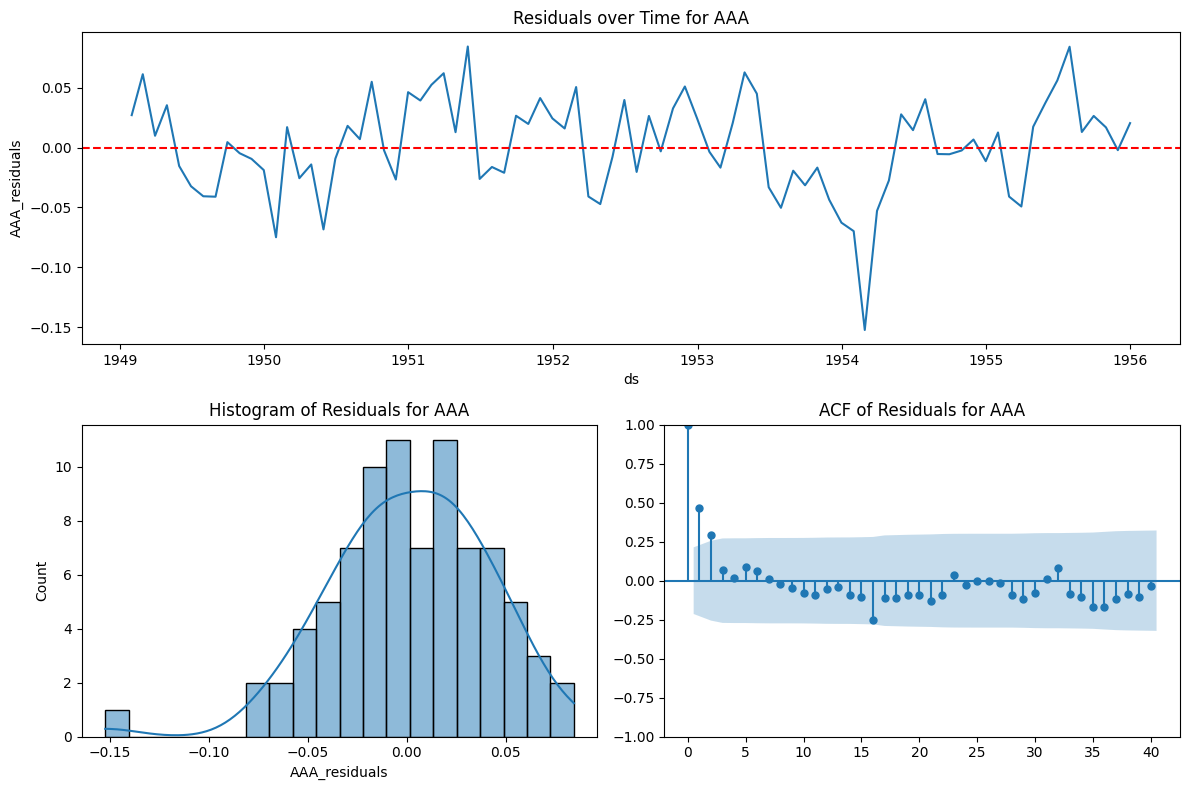


Ljung-Box test results:
Lag 6: p-value = 0.0001 (Significant autocorrelation)
Lag 12: p-value = 0.0028 (Significant autocorrelation)
Lag 24: p-value = 0.0040 (Significant autocorrelation)


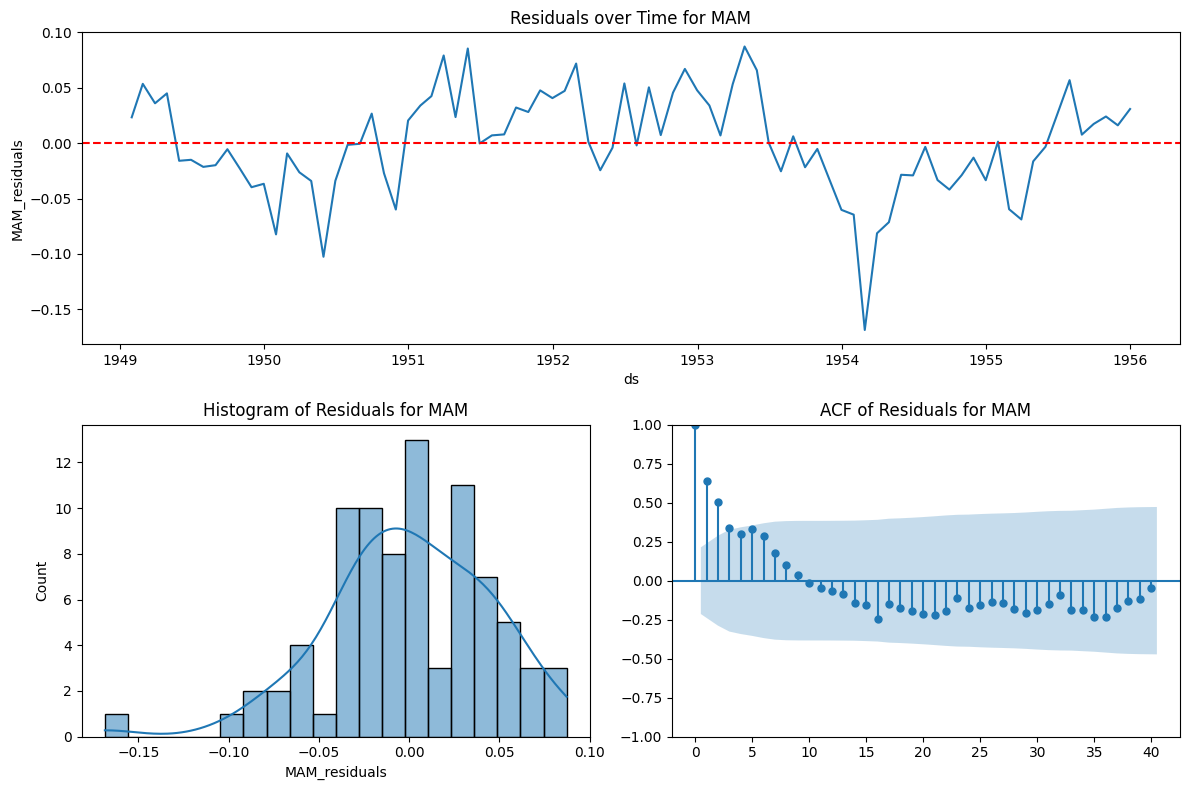


Ljung-Box test results:
Lag 6: p-value = 0.0000 (Significant autocorrelation)
Lag 12: p-value = 0.0000 (Significant autocorrelation)
Lag 24: p-value = 0.0000 (Significant autocorrelation)


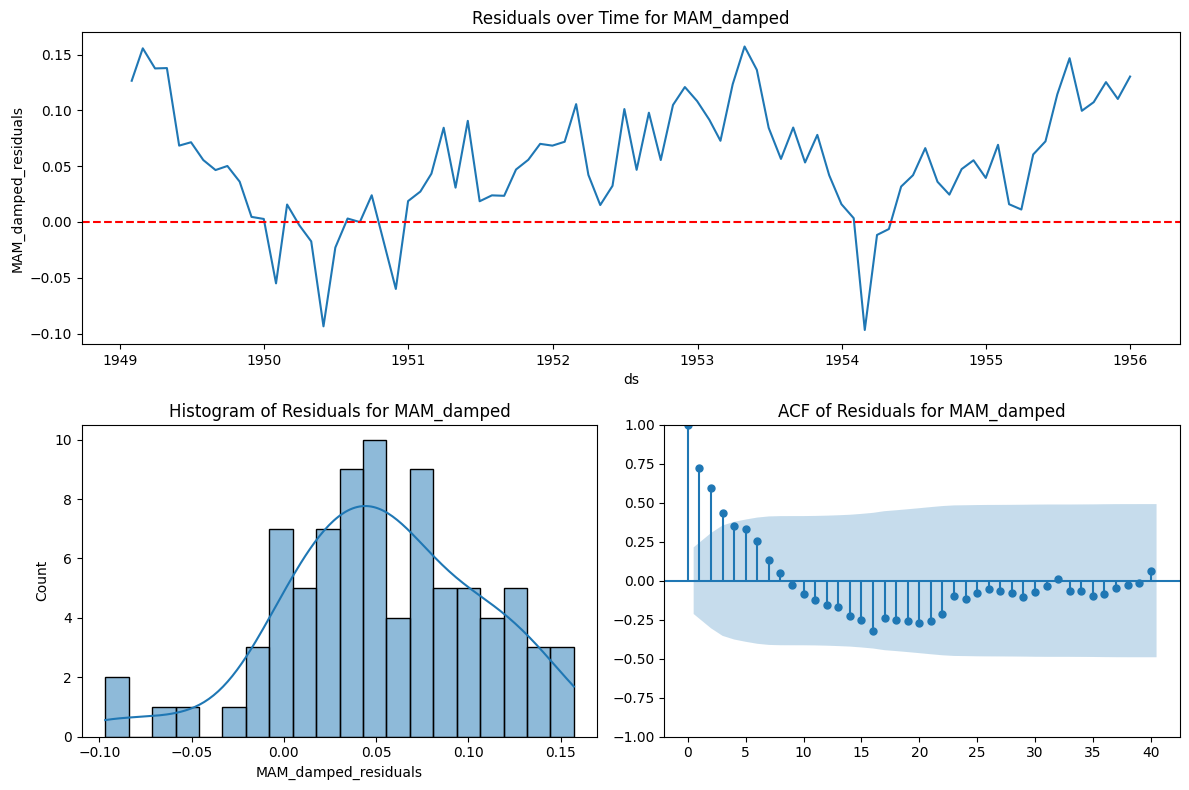


Ljung-Box test results:
Lag 6: p-value = 0.0000 (Significant autocorrelation)
Lag 12: p-value = 0.0000 (Significant autocorrelation)
Lag 24: p-value = 0.0000 (Significant autocorrelation)


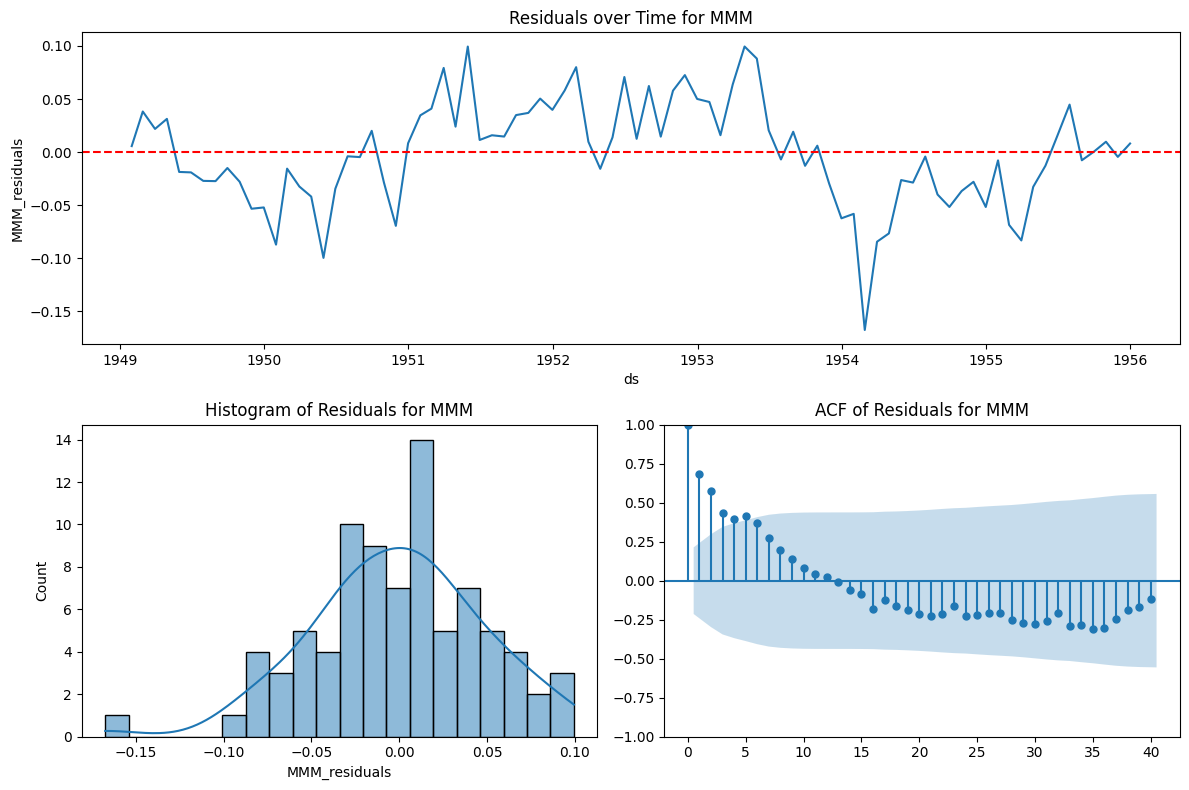


Ljung-Box test results:
Lag 6: p-value = 0.0000 (Significant autocorrelation)
Lag 12: p-value = 0.0000 (Significant autocorrelation)
Lag 24: p-value = 0.0000 (Significant autocorrelation)


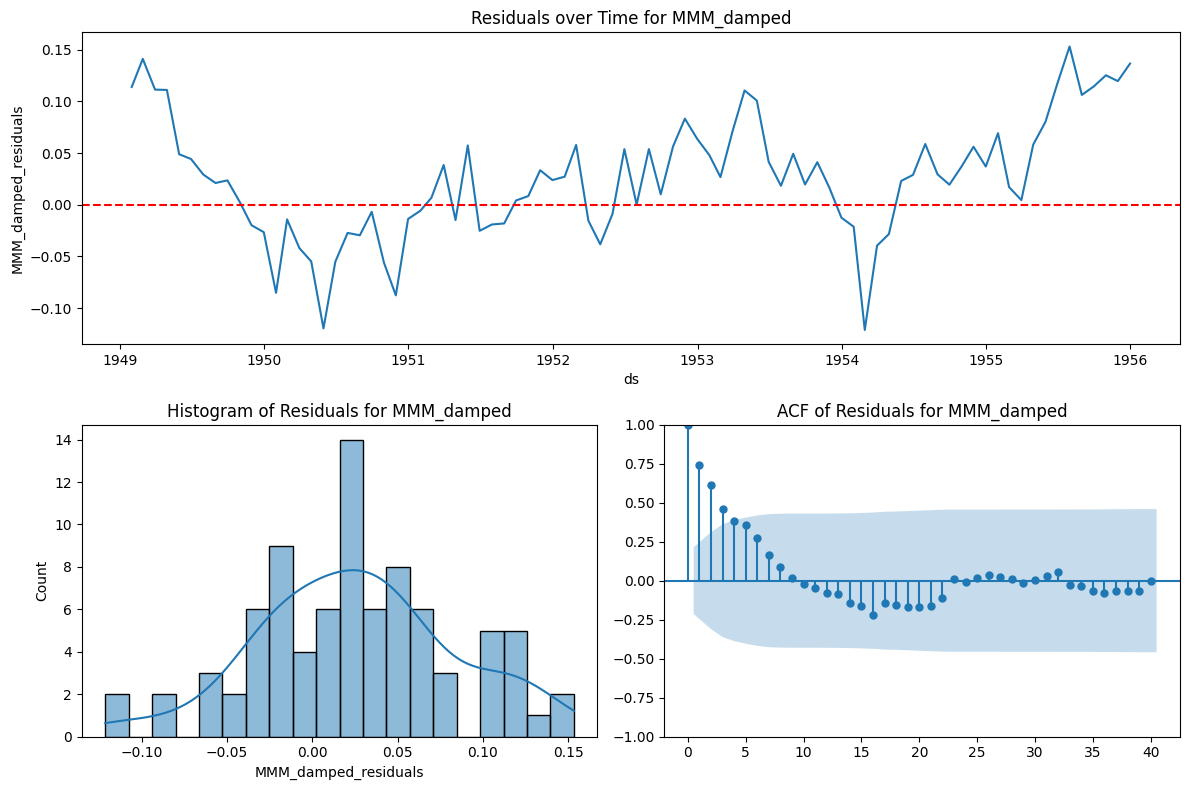


Ljung-Box test results:
Lag 6: p-value = 0.0000 (Significant autocorrelation)
Lag 12: p-value = 0.0000 (Significant autocorrelation)
Lag 24: p-value = 0.0000 (Significant autocorrelation)


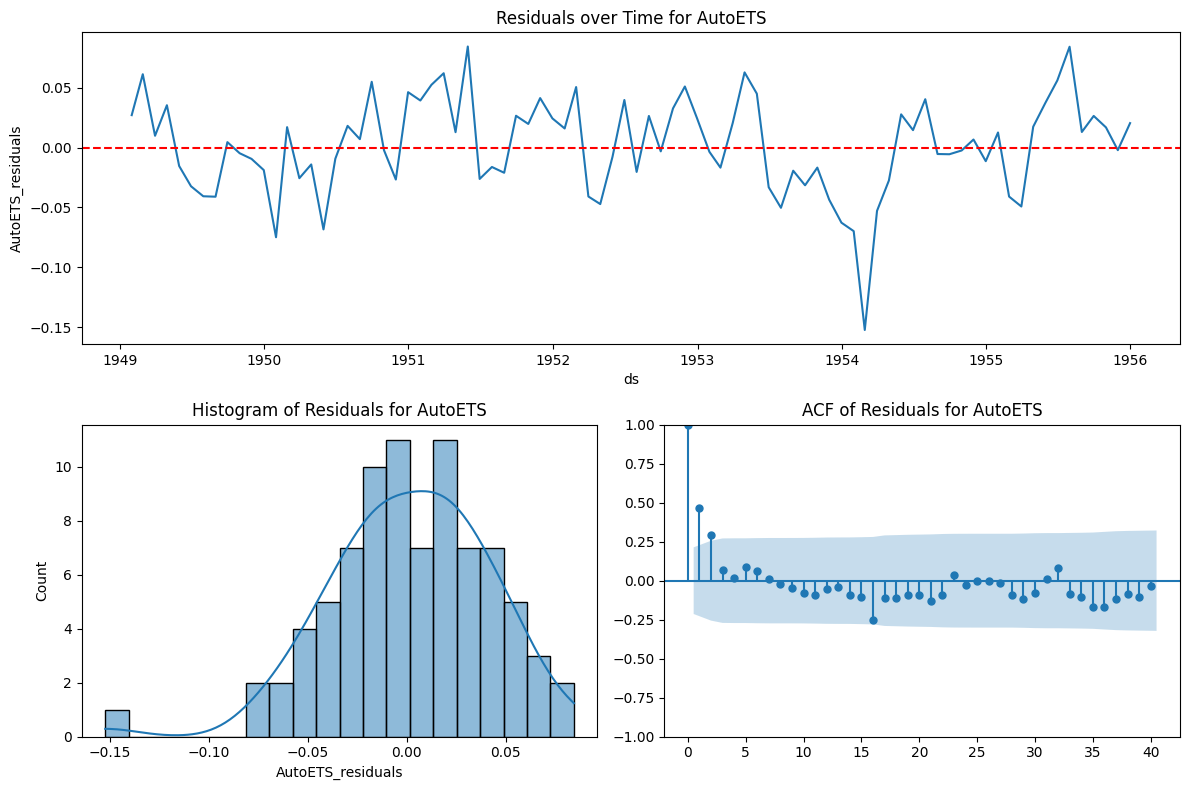


Ljung-Box test results:
Lag 6: p-value = 0.0001 (Significant autocorrelation)
Lag 12: p-value = 0.0028 (Significant autocorrelation)
Lag 24: p-value = 0.0040 (Significant autocorrelation)


In [656]:
df_new = AirPassengersDF.copy()
df_new['y'] = df_new['y'].apply(lambda x: np.log(x) if x > 0 else 0)  # Log-transform the target variable to stabilize variance
train = (df_new.loc[lambda x: (x['unique_id'] == 1) & (x['ds'] <= cutoff)])
test =  (df_new.loc[lambda x: (x['unique_id'] == 1) & (x['ds'] > cutoff)])

models = [
    AutoETS(season_length=12, model='AAA', alias='AAA'),
    AutoETS(season_length=12, model='MAM', alias='MAM'),
    AutoETS(season_length=12, model='MAM', damped= True, alias='MAM_damped'),
    AutoETS(season_length=12, model='MMM', alias='MMM'),
    AutoETS(season_length=12, model='MMM', damped = True, alias='MMM_damped'),
    AutoETS(season_length=12, alias='AutoETS'),  # Z = auto-select
]

# Fit and forecast with multiple models in one call:
sf = StatsForecast(models=models, freq='ME', n_jobs=-1)
sf.fit(df = train)
fitted_values = sf.forecast(df=train, h=test.shape[0], level=[80, 95], fitted=True)
fitted_values = sf.forecast_fitted_values()
forecast = sf.predict(h=test.shape[0],level=[80, 95])

# Merge true y back onto forecasts for plotting/eval
forecast = forecast.merge(test[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')
forecast.head()

## Evaluating the residuals of the fitted models:

col_names = ['unique_id', 'ds', 'y'] + [m.alias for m in sf.models]
residuals_df = fitted_values[fitted_values.columns.intersection(col_names)].copy()


# Plotting the residuals for each model:
for model in sf.models:
    plot_residual_diagnostics(residuals_df, model.alias)


# Converting the forecasts back to original scale for plotting:
train['y'] = np.exp(train['y'])
forecast['y'] = np.exp(forecast['y'])

for model in sf.models:
    forecast[f'{model}'] = np.exp(forecast[f'{model}'])
    forecast[f'{model}-lo-80'] = np.exp(forecast[f'{model}-lo-80'])
    forecast[f'{model}-hi-80'] = np.exp(forecast[f'{model}-hi-80'])
    forecast[f'{model}-lo-95'] = np.exp(forecast[f'{model}-lo-95'])
    forecast[f'{model}-hi-95'] = np.exp(forecast[f'{model}-hi-95'])

# Converting the fitted values back to original scale:
fitted_values['y'] = np.exp(fitted_values['y'])
for model in sf.models:
    fitted_values[f'{model}'] = np.exp(fitted_values[f'{model}'])
    fitted_values[f'{model}-lo-80'] = np.exp(fitted_values[f'{model}-lo-80'])
    fitted_values[f'{model}-hi-80'] = np.exp(fitted_values[f'{model}-hi-80'])
    fitted_values[f'{model}-lo-95'] = np.exp(fitted_values[f'{model}-lo-95'])
    fitted_values[f'{model}-hi-95'] = np.exp(fitted_values[f'{model}-hi-95'])



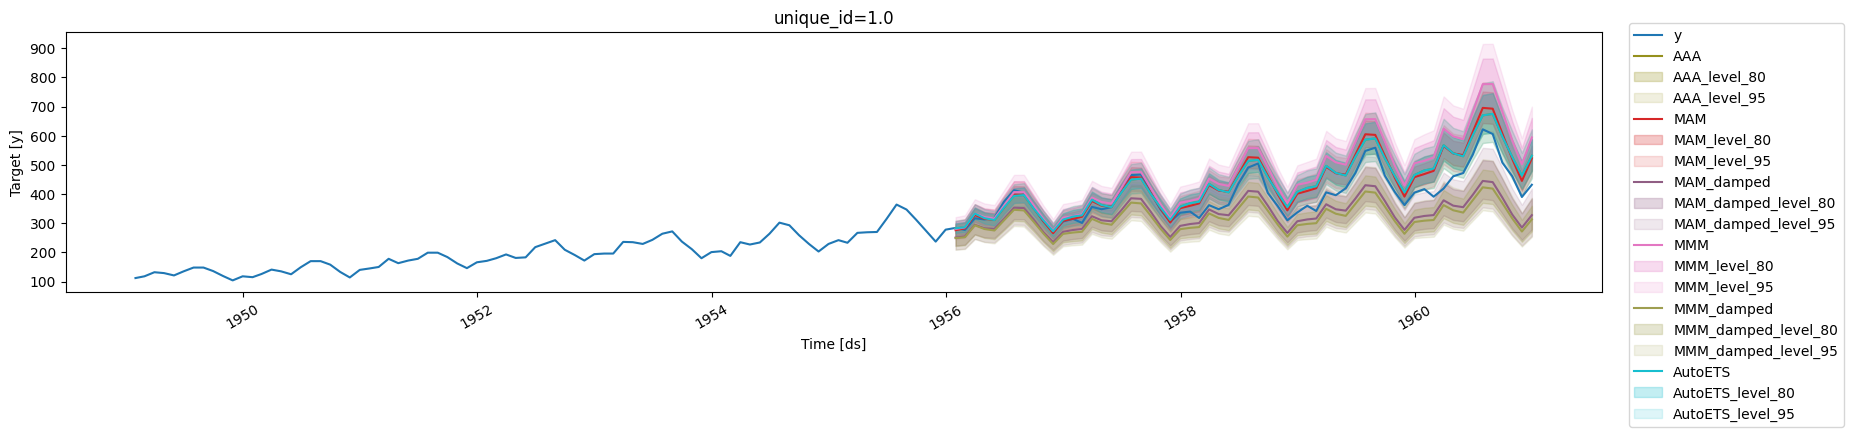

In [657]:
# Plotting the time series:
plot_series(train, forecast, level=[80, 95])

### Evaluation of all the ETS Models:

In [658]:
eval_metrics = ['loglik', 'aic', 'bic', 'aicc', 'mse', 'amse']
all_results = []

for model in sf.fitted_[0]:
    eval_metrics_results = {k:v for k,v in model.model_.items() if k in eval_metrics}
    all_results.append(eval_metrics_results)
all_results_df = pd.DataFrame(all_results, index=[m.alias for m in sf.models])
print(all_results_df)

# Further Evaluation of the forecasted values:
ets_forecast_eval = evaluate(forecast, metrics=[mae, rmse, mape, smape, mse])
print(ets_forecast_eval)


               loglik         aic        bic        aicc       mse      amse
AAA         84.741907 -135.483814 -94.159929 -126.211087  0.001583  0.001893
MAM         74.160416 -114.320833 -72.996947 -105.048106  0.002026  0.002149
MAM_damped  31.236506  -26.473012  17.281691  -15.949935  0.005630  0.005504
MMM         67.950294 -101.900588 -60.576702  -92.627860  0.002350  0.002450
MMM_damped  45.955463  -55.910927 -12.156224  -45.387850  0.003978  0.003950
AutoETS     84.741907 -135.483814 -94.159929 -126.211087  0.001583  0.001893
   unique_id metric          AAA          MAM   MAM_damped          MMM  \
0        1.0    mae    40.995756    39.924933    65.286953    67.579343   
1        1.0   rmse    51.919775    51.464604    75.268918    86.472989   
2        1.0   mape     0.101070     0.096175     0.155524     0.160566   
3        1.0  smape     0.046908     0.044725     0.085565     0.071599   
4        1.0    mse  2695.663080  2648.605455  5665.410008  7477.577811   

    MMM_da

AutoETS fit the training data best. It picked some spec that beats MMM on AICc by ~5 points.
AutoETS generalized worst — despite fitting training data best.
This is a textbook overfitting result, and it's the single most important lesson in model selection. Let me walk you through it.
AutoETS optimized for AICc, which rewards good fit while penalizing complexity. It picked a spec that fit the 84 training points very well — probably with flexible smoothing parameters that adapted aggressively to training noise. But that aggressiveness didn't generalize; on the 60-month test horizon it drifted badly.
Meanwhile MMM, with the simpler and more constrained "multiplicative-trend-multiplicative-seasonality" structure, didn't fit training as well but its constraints kept it honest when extrapolating.    


AICc is a proxy for generalization, not a guarantee of it. It's based on in-sample likelihood plus a complexity penalty. It works well when the training data is a faithful sample of the forecast distribution. It fails when the forecast period diverges from the training period — which, for trending time series, it always does.

On AirPassengers I compared 4 ETS specifications plus AutoETS. AutoETS won on AICc but placed last on test MAPE — a 2.3x worse error than the simpler MMM spec I picked from domain reasoning. This is a classic overfitting signature: AICc's complexity penalty wasn't strong enough on 84 training points, and the selected model captured training noise. The takeaway is that model selection on time series requires rolling-origin CV, not information criteria alone. Expert-informed manual specs can outperform auto-selection, especially on short series.

### Previous floor: RWD 0.14. New floor: MMM at 0.0999. Any ARIMA, Prophet, or ML model you try from here on must beat this.

I compared 5 ETS specifications on 84 months of training data. AutoETS picked the model with the best in-sample fit (clean residual ACF, AIC 767) but it placed last on test MAPE (0.23). The manually-chosen MMM — which I selected based on the series' exponential trend — had imperfect residuals (lag-1 autocorrelation, right skew) but won on test MAPE (0.10). The clean-residuals-bad-test-MAPE pattern is the signature of overfitting: AutoETS absorbed training noise into its parameters, and that noise extrapolated as bias. The takeaway: residual diagnostics measure fit quality; only held-out evaluation measures generalization. On short series, domain-informed model selection often beats AIC-driven auto-selection

MMM: all three lags reject white noise hard (p < 0.0001). Consistent with the ACF showing bars at lags 1-8 and a clear sinusoidal pattern. Confirmed: MMM leaves exploitable short-lag + seasonal-lag structure.
AutoETS: this is the more nuanced read.

Lag 6: p = 0.01 → reject (barely)
Lag 12: p = 0.13 → fail to reject
Lag 24: p = 0.22 → fail to reject

AutoETS's residuals are white noise at seasonal and longer lags, but retain some short-lag autocorrelation at lag 6 and below. Translation: AutoETS absorbed the seasonal signal completely (including the noise in it, which is why lags 12, 24 are dead), but has minor short-term dynamics unaccounted for.
So to refine your claim slightly: not all models "fail" Ljung-Box. AutoETS passes at lags 12 and 24 and fails only at lag 6. That's a meaningful difference from MMM.
But it doesn't rescue AutoETS's test MAPE:
Residual quality is not test performance. AutoETS still generalized worst (0.227 MAPE) despite cleaner diagnostics. The earlier lesson holds: clean residuals ≠ good forecasts.
The more important takeaway from your comparison:
No ETS variant achieved truly clean residuals AND good test MAPE. That's not a failure — that's the signal telling you ETS is reaching its limits on this series. The data has structure that ETS's smoothing framework can't fully capture. Specifically:

Evolving multiplicative seasonality (MMM captures it structurally but imperfectly)
Short-lag autocorrelation in residuals
Possibly non-stationary variance even in log space

This is where ARIMA enters. ARIMA attacks the problem from a completely different angle — it doesn't assume smoothing; it models the autocorrelation structure directly. If SARIMA can get both test MAPE < 0.10 AND cleaner residuals at lag 6, we'll have found the right framework for this data.



Fair. Tighter version:

---

# Day 1 + Day 2 Summary

## Dataset
AirPassengersDF, 144 monthly obs (1949-1960). Train/test split at 1955-12-31.

## Process
Hypothesize → plot → quantify → decompose → diagnose → pick transform → baseline → fit → evaluate → iterate.

## Day 1
- Hypothesized trend + seasonality from domain context before plotting
- Log-transform revealed exponential trend, multiplicative seasonality
- STL on log-y: seasonal effect 80%-131% of trend
- Residual diagnostics (ACF, Ljung-Box at 6/12/24) all rejected white noise
- Ran 5 baselines with conformal PIs
- **Result: RWD won at MAPE 0.14, beat SeasonalNaive (0.27)**
- Lesson: long horizon → trend matters more than seasonality

## Day 2
Compared 5 ETS specs on raw-y and log-y.

| Model | Raw-y MAPE | Log-y MAPE |
|---|---|---|
| MAM | 0.102 | **0.096** |
| MMM | **0.100** | 0.161 |
| AAA | — | 0.101 |
| AutoETS | 0.227 | 0.101 |

**Key findings:**
1. AutoETS on raw-y overfit (best AICc, worst test MAPE) → residual diagnostics measure fit, not generalization
2. Log-transform + multiplicative ETS = double-correction. Coherent paths: raw-y+MMM or log-y+AAA
3. All coherent paths converge to ~0.10 MAPE → ETS ceiling on this data
4. Residuals still show lag 1-6 autocorrelation → ARIMA territory

## Bugs fixed (API fluency)
- `.loc[]` vs `.loc()`, `&` precedence, `h` vs `horizon`
- In-sample residuals ≠ forecast errors (caught twice)
- ConformalIntervals needed for non-analytical baselines
- `.forecast(fitted=True)` is the workhorse, not `.fit()` + `.predict()`

## Portable principles
1. Hypothesize before plotting
2. Transform is a modeling decision, not preprocessing
3. Baselines are mandatory — fancy models must beat them
4. Horizon changes the winner
5. Residual diagnostics measure fit; test MAPE measures generalization
6. Sanity-check date ranges before trusting any plot
7. AIC/BIC on short series underpenalize — trust CV instead

## Current state
- Floor to beat: **MAPE ~0.10**
- Log-y pipeline ready for ARIMA
- Hypothesis: SARIMA captures the lag 1-6 structure ETS misses

# ARIMA Models:


In [659]:
from statsforecast.models import AutoARIMA, ARIMA

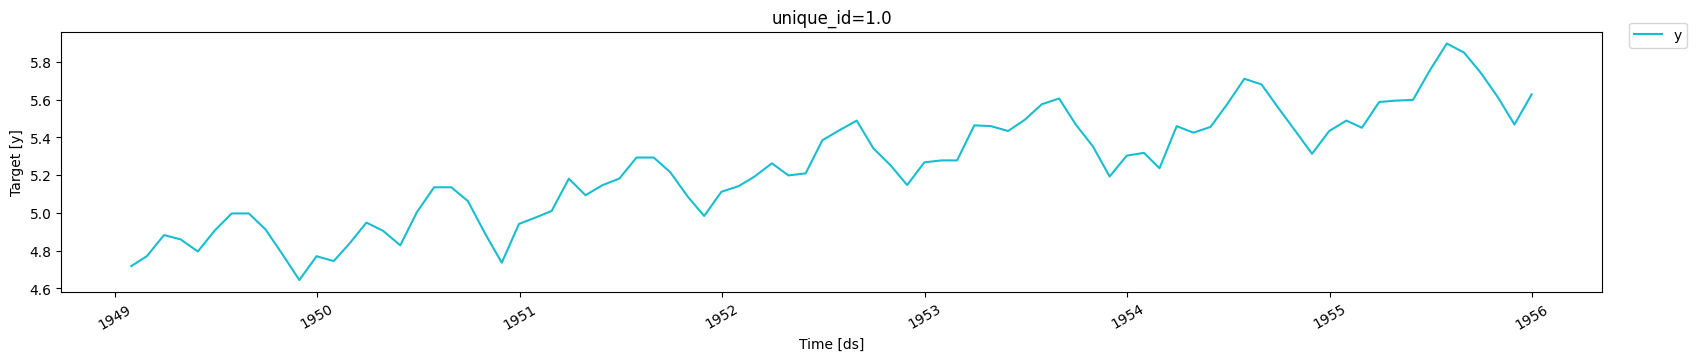

In [670]:
# First I will difference the log transformed series to make it stationary and capture seasolnality with seasonal differencing:
# Then I will perform the KPSS test to confirm stationarity and then plot ACF and PACF to identify potential AR and MA terms.

df_new = AirPassengersDF.copy()
df_new['y'] = df_new['y'].apply(lambda x: np.log(x) if x > 0 else 0)  # Log-transform the target variable to stabilize variance
train = (df_new.loc[lambda x: (x['unique_id'] == 1) & (x['ds'] <= cutoff)])
test =  (df_new.loc[lambda x: (x['unique_id'] == 1) & (x['ds'] > cutoff)])

# Step 1: Applying log transformation to stabilize variance and make the series more stationary:
plot_series(train)

KPSS Statistic: 0.0997, p-value: 0.1000
ADF stat = -11.5650, p = 0.0000
  → stationary


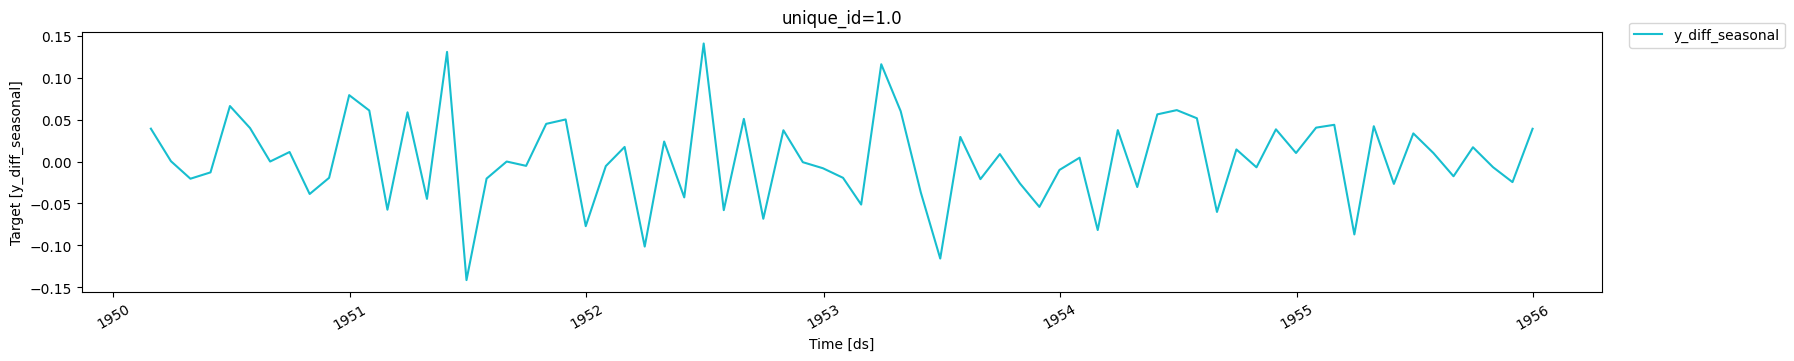

In [671]:
# Step 2: Differencing to remove seasonality and trend:
train['y_diff'] = train['y'] - train['y'].shift(1)   # Shifting the series by 1 to get the first difference
train['y_diff_seasonal'] = train['y_diff'] - train['y_diff'].shift(12)  # Seasonal differencing with lag 12 for monthly data
diffed = train.iloc[13:,:]  # Drop the first 12 rows which will be NaN after seasonal differencing

# Performing KPSS test to confirm stationarity:
from statsmodels.tsa.stattools import kpss, adfuller

stat, p, *_ = adfuller(diffed['y_diff_seasonal'])
statistic, p_value, *_ = kpss(diffed['y_diff_seasonal'], nlags = 5)
print(f"KPSS Statistic: {statistic:.4f}, p-value: {p_value:.4f}")

print(f"ADF stat = {stat:.4f}, p = {p:.4f}")
print(f"  → {'stationary' if p < 0.05 else 'non-stationary'}")

plot_series(train, target_col='y_diff_seasonal')


### From the above exercise, we established that based on KPSS ad ADFULLER metrics, that d=1 and D = 1 are required to remove the seasonality and trend information

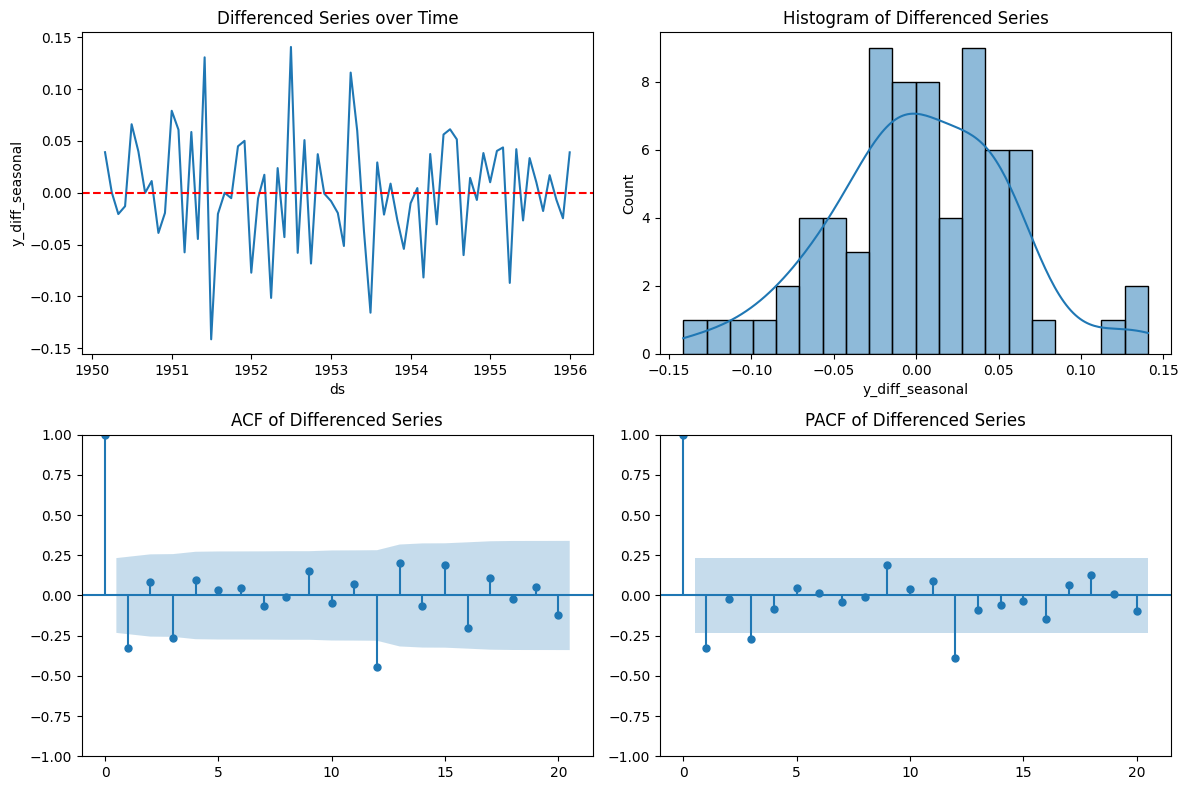

In [672]:

# Residual diagonostics for the differenced series:
fig,axes = plt.subplot_mosaic([['residual_trend', 'histogram'], ['acf', 'pacf']], figsize=(12, 8))
# Residual plot
sns.lineplot(x= 'ds', y='y_diff_seasonal', data=diffed, ax=axes['residual_trend'])
axes['residual_trend'].set_title('Differenced Series over Time')
axes['residual_trend'].axhline(0, color='red', linestyle='--')
# Histogram of residuals:
sns.histplot(diffed['y_diff_seasonal'], bins=20, kde=True, ax=axes['histogram'])
axes['histogram'].set_title('Histogram of Differenced Series')
# ACF of residuals:
plot_acf(diffed['y_diff_seasonal'].dropna(), lags=20, ax=axes['acf'])
axes['acf'].set_title('ACF of Differenced Series')
# PACF of residuals:
plot_pacf(diffed['y_diff_seasonal'].dropna(), lags=20, ax=axes['pacf'])
axes['pacf'].set_title('PACF of Differenced Series')
plt.tight_layout()
plt.show()

ACF (top-left):

Lag 1: −0.32 (clearly significant, large)
Lag 2: −0.03 (tiny, noise)
Lag 3: −0.25 (significant but smaller)
Lags 4-11: mostly inside the band
Lag 12: −0.48 (huge, clearly significant)
Lags after 12: mostly inside the band

PACF (bottom-right):

Lag 1: −0.32 (large)
Lag 2: −0.03 (tiny)
Lag 3: −0.23 (significant)
Lags 4-11: most inside the band, some borderline
Lag 12: −0.38 (large)
Lags after 12: decaying

Both ACF and PACF show a big spike at lag 1, something at lag 3, then noise. 
Reasonable candidates: (1,0), (0,1), (1,1).

### Seasonal (lags 12, 24):

ACF lag 12: huge spike (−0.48), lag 24: quiet → Q=1
PACF lag 12: also big (−0.38), lag 24: decaying → tails off

When ACF has one sharp seasonal spike and PACF tails off at seasonal lags → Q=1, P=0. 

### Lets try: SARIMA(0,1,1)(0,1,1)[12] and SARIMA (1,1,1)(0,1,1)[12] and SARIMA (1,1,1)(1,1,1)[12] and measure performance

In [ ]:
from statsforecast.models import ARIMA, AutoARIMA

train_arima = train[['unique_id', 'ds', 'y']].copy()

models = [
    ARIMA(order=(1,1,1), seasonal_order=(0,1,1), season_length=12, alias='SARIMA_111_011'),
    ARIMA(order=(0,1,1), seasonal_order=(0,1,1), season_length=12, alias='SARIMA_011_011'),
    ARIMA(order=(1,1,1), seasonal_order=(1,1,1), season_length=12, alias='SARIMA_111_111'),
    ARIMA(order=(2,1,2), seasonal_order=(0,1,1), season_length=12, alias='SARIMA_212_011'),
    AutoARIMA(season_length=12, alias='AutoARIMA')
]

fc = StatsForecast(models=models, freq='ME', n_jobs=-1)
fc.fit(df=train_arima)
forecast = fc.forecast(df=train_arima, h=test.shape[0], level=[80,95], fitted=True)
fitted_values = fc.forecast_fitted_values()

# Back-transform forecasts to raw scale
model_cols = [m.alias for m in fc.models]

for alias in model_cols:
    forecast[alias] = np.exp(forecast[alias])
    fitted_values[alias] = np.exp(fitted_values[alias])
    for lvl in [80, 95]:
        forecast[f'{alias}-lo-{lvl}'] = np.exp(forecast[f'{alias}-lo-{lvl}'])
        forecast[f'{alias}-hi-{lvl}'] = np.exp(forecast[f'{alias}-hi-{lvl}'])
        fitted_values[f'{alias}-lo-{lvl}'] = np.exp(fitted_values[f'{alias}-lo-{lvl}'])
        fitted_values[f'{alias}-hi-{lvl}'] = np.exp(fitted_values[f'{alias}-hi-{lvl}'])

fitted_values['y'] = np.exp(fitted_values['y'])

# Merge with raw test y (not log test y)
raw_test = AirPassengersDF[AirPassengersDF['ds'] > cutoff][['unique_id','ds','y']]
forecast = forecast.merge(raw_test, on=['unique_id','ds'], how='left')

results = evaluate(forecast, metrics=[mae, rmse, mape, smape])
print(results)

   unique_id metric  AutoARIMA
0        1.0    mae  31.060981
1        1.0   rmse  39.843218
2        1.0   mape   0.074902
3        1.0  smape   0.035406


In [720]:
def describe_arima(fitted_model, alias):
    m = fitted_model.model_
    arma = m.get('arma', None)
    if arma is not None:
        p, q, P, Q, s, d, D = arma
        print(f"{alias}: ARIMA({p},{d},{q})({P},{D},{Q})[{s}]")
        print(f"  AIC={m.get('aic', 'n/a'):.2f}, BIC={m.get('bic', 'n/a'):.2f}")
    else:
        print(f"{alias}: couldn't extract order, keys = {list(m.keys())}")

for i, alias in enumerate(model_cols):
    describe_arima(fc.fitted_[0, i], alias)


AutoARIMA: ARIMA(2,0,0)(2,1,0)[12]
  AIC=-239.87, BIC=-226.21


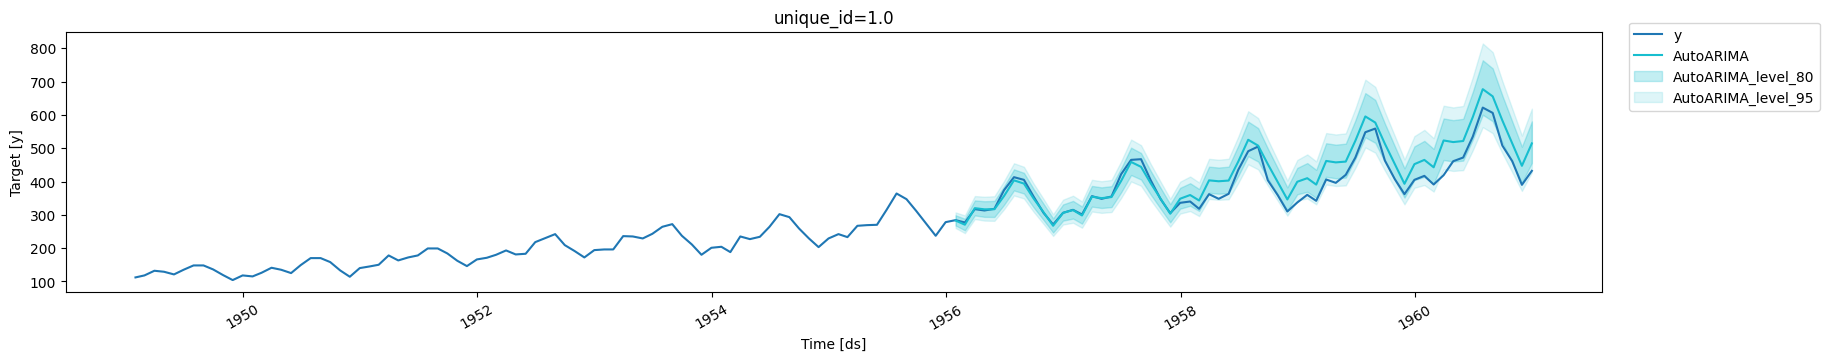

In [721]:
train_copy = train.copy()
train_copy['y'] = np.exp(train_copy['y'])
plot_series(train_copy, forecast,level=[80, 95])

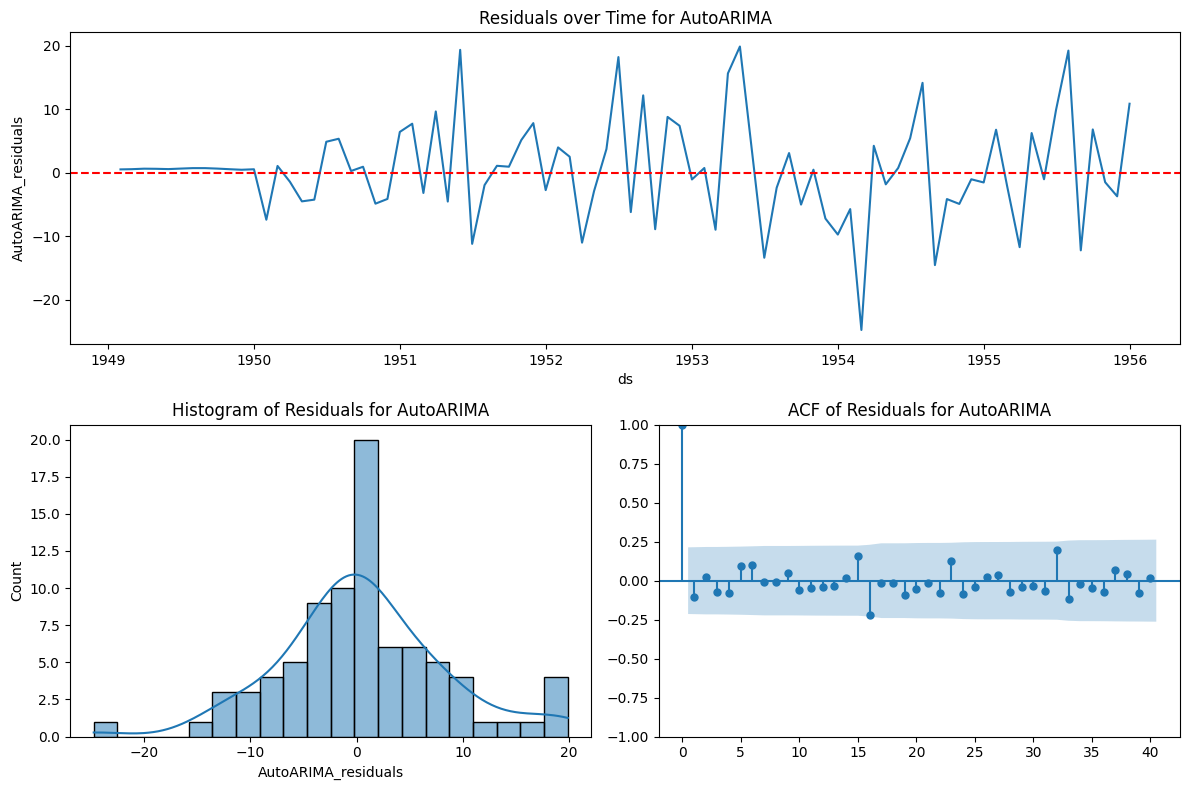


Ljung-Box test results:
Lag 6: p-value = 0.7114 (No significant autocorrelation)
Lag 12: p-value = 0.9664 (No significant autocorrelation)
Lag 24: p-value = 0.8153 (No significant autocorrelation)


In [722]:
# Residual diagnostics for the ARIMA model:
for alias in model_cols:
    plot_residual_diagnostics(fitted_values, alias)

On AirPassengers, I did the classical Box-Jenkins workflow — stationarity tests, ACF/PACF reading, manual order selection — and landed on SARIMA(1,1,1)(0,1,1)[12] with MAPE 0.101. AutoARIMA picked a non-obvious (2,0,0)(2,1,0)[12] and achieved 0.075 — a 26% improvement. The takeaway isn't that automated selectors always win; earlier the same day AutoETS overfit on raw-y and picked the worst model by test MAPE. The lesson is that manual selection encodes your assumptions about the data-generating process, and if those assumptions are slightly wrong, the wider search space of automated selection can find a better spec. Use both in practice — manual for interpretability, auto for performance, and reconcile differences with held-out evaluation.

I ran four ETS variants and four SARIMA variants on AirPassengers, evaluating both residual white-noise properties and held-out test MAPE. The most instructive finding was the decoupling of fit and generalization: AutoETS had the cleanest in-sample residuals but the worst test MAPE (overfit); manual SARIMA had the worst residuals (lag-1 structure remaining) but matched ETS on test MAPE. Only AutoARIMA, with its unusual AR-heavy spec, achieved both clean residuals (Ljung-Box p > 0.7 at all tested lags) and the best test MAPE (0.075 vs the 0.10 ceiling of ETS). This is the rare case where automated selection genuinely beats domain-reasoning, and the residual diagnostics confirm it's not a lucky MAPE outcome — the model actually extracted all the signal.